In [11]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [12]:
df=pd.read_csv("Train.csv")
df
df["Reached.on.Time_Y.N"].value_counts()

df['Cost_per_gram'] = df['Cost_of_the_Product'] / (df['Weight_in_gms'] )
df['Discount_ratio'] = df['Discount_offered'] / (df['Cost_of_the_Product'] )  
df['Rating_vs_calls'] = df['Customer_rating'] / (df['Customer_care_calls'] + 1)

In [13]:

#Just an identifier, does not affect shipment delivery. Should be dropped
df.drop("ID", axis=1, inplace=True) 
target=df["Reached.on.Time_Y.N"]
df.drop("Reached.on.Time_Y.N", axis=1, inplace=True) 
df

,Warehouse_block,Mode_of_Shipment,Customer_care_calls,Customer_rating,Cost_of_the_Product,Prior_purchases,Product_importance,Gender,Discount_offered,Weight_in_gms,Cost_per_gram,Discount_ratio,Rating_vs_calls
0,D,Flight,4,2,177,3,low,F,44,1233,0.143552,0.248588,0.400000
1,F,Flight,4,5,216,2,low,M,59,3088,0.069948,0.273148,1.000000
2,A,Flight,2,2,183,4,low,M,48,3374,0.054238,0.262295,0.666667
3,B,Flight,3,3,176,4,medium,M,10,1177,0.149533,0.056818,0.750000
4,C,Flight,2,2,184,3,medium,F,46,2484,0.074074,0.250000,0.666667
...,...,...,...,...,...,...,...,...,...,...,...,...,...
10994,A,Ship,4,1,252,5,medium,F,1,1538,0.163849,0.003968,0.200000
10995,B,Ship,4,1,232,5,medium,F,6,1247,0.186047,0.025862,0.200000
10996,C,Ship,5,4,242,5,low,F,4,1155,0.209524,0.016529,0.666667
10997,F,Ship,5,2,223,6,medium,M,2,1210,0.184298,0.008969,0.333333


In [14]:
df_num = df.select_dtypes(include=np.number)
df_cat=df.select_dtypes(exclude=np.number)

### Check Distribution of Numerical Features
- If data is normally distributed → use StandardScaler.

- If data is skewed / has outliers → use RobustScaler or log transform.

- If you need values between 0–1 → use MinMaxScaler.

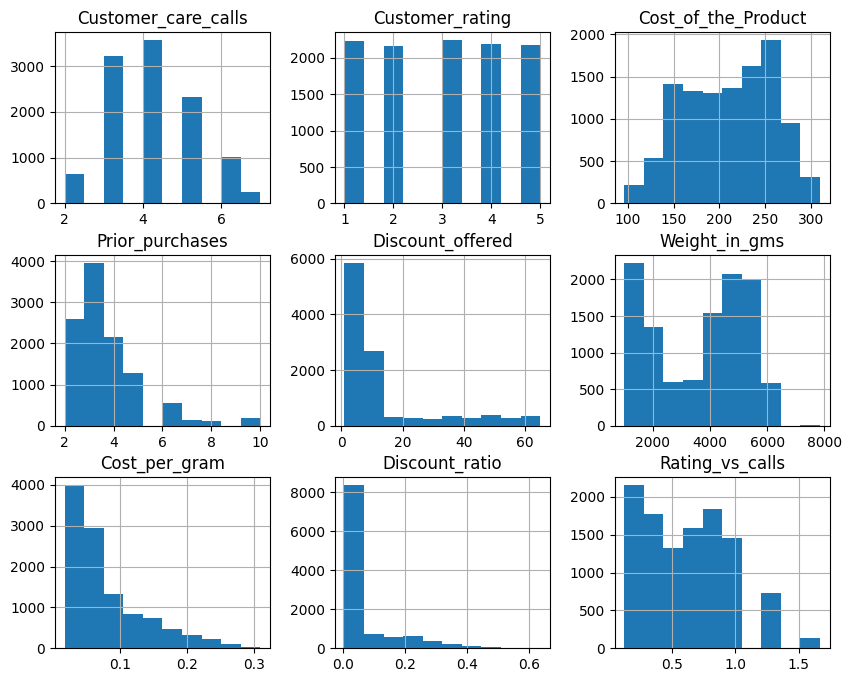

In [15]:
df_num.hist(figsize=(10,8))
plt.show()

Skewness ≈ 0 → Nearly normal → StandardScaler is fine

Skewness > +1 or < -1 → Highly skewed → RobustScaler or log transform

In [16]:
df_num.skew()

Customer_care_calls    0.391926
Customer_rating        0.004360
Cost_of_the_Product   -0.157117
Prior_purchases        1.681897
Discount_offered       1.798929
Weight_in_gms         -0.249747
Cost_per_gram          1.419781
Discount_ratio         2.172764
Rating_vs_calls        0.581421
dtype: float64

In [17]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
df[["Customer_care_calls","Customer_rating","Cost_of_the_Product","Weight_in_gms"]] = scaler.fit_transform(df[["Customer_care_calls","Customer_rating","Cost_of_the_Product","Weight_in_gms"]])
df

,Warehouse_block,Mode_of_Shipment,Customer_care_calls,Customer_rating,Cost_of_the_Product,Prior_purchases,Product_importance,Gender,Discount_offered,Weight_in_gms,Cost_per_gram,Discount_ratio,Rating_vs_calls
0,D,Flight,-0.047711,-0.700755,-0.690722,3,low,F,44,-1.468240,0.143552,0.248588,0.400000
1,F,Flight,-0.047711,1.421578,0.120746,2,low,M,59,-0.333893,0.069948,0.273148,1.000000
2,A,Flight,-1.799887,-0.700755,-0.565881,4,low,M,48,-0.159002,0.054238,0.262295,0.666667
3,B,Flight,-0.923799,0.006689,-0.711529,4,medium,M,10,-1.502484,0.149533,0.056818,0.750000
4,C,Flight,-1.799887,-0.700755,-0.545074,3,medium,F,46,-0.703244,0.074074,0.250000,0.666667
...,...,...,...,...,...,...,...,...,...,...,...,...,...
10994,A,Ship,-0.047711,-1.408199,0.869792,5,medium,F,1,-1.281730,0.163849,0.003968,0.200000
10995,B,Ship,-0.047711,-1.408199,0.453655,5,medium,F,6,-1.459679,0.186047,0.025862,0.200000
10996,C,Ship,0.828377,0.714133,0.661724,5,low,F,4,-1.515937,0.209524,0.016529,0.666667
10997,F,Ship,0.828377,-0.700755,0.266394,6,medium,M,2,-1.482304,0.184298,0.008969,0.333333


In [18]:
from sklearn.preprocessing import StandardScaler, RobustScaler

scaler_rob = RobustScaler()
df[["Prior_purchases","Discount_offered","Cost_per_gram","Discount_ratio"]]= scaler_rob .fit_transform(df[["Prior_purchases","Discount_offered","Cost_per_gram","Discount_ratio"]])
df

,Warehouse_block,Mode_of_Shipment,Customer_care_calls,Customer_rating,Cost_of_the_Product,Prior_purchases,Product_importance,Gender,Discount_offered,Weight_in_gms,Cost_per_gram,Discount_ratio,Rating_vs_calls
0,D,Flight,-0.047711,-0.700755,-0.690722,0.0,low,F,6.166667,-1.468240,1.391818,4.739118,0.400000
1,F,Flight,-0.047711,1.421578,0.120746,-1.0,low,M,8.666667,-0.333893,0.236050,5.279853,1.000000
2,A,Flight,-1.799887,-0.700755,-0.565881,1.0,low,M,6.833333,-0.159002,-0.010634,5.040908,0.666667
3,B,Flight,-0.923799,0.006689,-0.711529,1.0,medium,M,0.500000,-1.502484,1.485725,0.517051,0.750000
4,C,Flight,-1.799887,-0.700755,-0.545074,0.0,medium,F,6.500000,-0.703244,0.300837,4.770215,0.666667
...,...,...,...,...,...,...,...,...,...,...,...,...,...
10994,A,Ship,-0.047711,-1.408199,0.869792,2.0,medium,F,-1.000000,-1.281730,1.710529,-0.646513,0.200000
10995,B,Ship,-0.047711,-1.408199,0.453655,2.0,medium,F,-0.166667,-1.459679,2.059082,-0.164490,0.200000
10996,C,Ship,0.828377,0.714133,0.661724,2.0,low,F,-0.500000,-1.515937,2.427734,-0.369972,0.666667
10997,F,Ship,0.828377,-0.700755,0.266394,3.0,medium,M,-0.833333,-1.482304,2.031619,-0.536423,0.333333


In [19]:
from sklearn.preprocessing import OneHotEncoder
import pandas as pd

encoder = OneHotEncoder(sparse_output=False,drop="first")
encoded = encoder.fit_transform(df[["Warehouse_block","Mode_of_Shipment","Product_importance","Gender"]])

print(encoded)
print(encoder.get_feature_names_out())

[[0. 0. 1. ... 1. 0. 0.]
 [0. 0. 0. ... 1. 0. 1.]
 [0. 0. 0. ... 1. 0. 1.]
 ...
 [0. 1. 0. ... 1. 0. 0.]
 [0. 0. 0. ... 0. 1. 1.]
 [0. 0. 1. ... 1. 0. 0.]]
['Warehouse_block_B' 'Warehouse_block_C' 'Warehouse_block_D'
 'Warehouse_block_F' 'Mode_of_Shipment_Road' 'Mode_of_Shipment_Ship'
 'Product_importance_low' 'Product_importance_medium' 'Gender_M']


In [20]:
df_encoded = pd.DataFrame(encoded,columns = encoder.get_feature_names_out())
df = pd.concat([df,df_encoded],axis=1)
df

,Warehouse_block,Mode_of_Shipment,Customer_care_calls,Customer_rating,Cost_of_the_Product,Prior_purchases,Product_importance,Gender,Discount_offered,Weight_in_gms,...,Rating_vs_calls,Warehouse_block_B,Warehouse_block_C,Warehouse_block_D,Warehouse_block_F,Mode_of_Shipment_Road,Mode_of_Shipment_Ship,Product_importance_low,Product_importance_medium,Gender_M
0,D,Flight,-0.047711,-0.700755,-0.690722,0.0,low,F,6.166667,-1.468240,...,0.400000,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0
1,F,Flight,-0.047711,1.421578,0.120746,-1.0,low,M,8.666667,-0.333893,...,1.000000,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,1.0
2,A,Flight,-1.799887,-0.700755,-0.565881,1.0,low,M,6.833333,-0.159002,...,0.666667,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0
3,B,Flight,-0.923799,0.006689,-0.711529,1.0,medium,M,0.500000,-1.502484,...,0.750000,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,1.0
4,C,Flight,-1.799887,-0.700755,-0.545074,0.0,medium,F,6.500000,-0.703244,...,0.666667,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
10994,A,Ship,-0.047711,-1.408199,0.869792,2.0,medium,F,-1.000000,-1.281730,...,0.200000,0.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0
10995,B,Ship,-0.047711,-1.408199,0.453655,2.0,medium,F,-0.166667,-1.459679,...,0.200000,1.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0
10996,C,Ship,0.828377,0.714133,0.661724,2.0,low,F,-0.500000,-1.515937,...,0.666667,0.0,1.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0
10997,F,Ship,0.828377,-0.700755,0.266394,3.0,medium,M,-0.833333,-1.482304,...,0.333333,0.0,0.0,0.0,1.0,0.0,1.0,0.0,1.0,1.0


In [21]:
df.drop(["Warehouse_block","Mode_of_Shipment","Product_importance","Gender"],axis=1,inplace=True)

In [22]:
from sklearn.model_selection import train_test_split

X = df  # features
y=target        # target

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42,stratify=y) 
X


,Customer_care_calls,Customer_rating,Cost_of_the_Product,Prior_purchases,Discount_offered,Weight_in_gms,Cost_per_gram,Discount_ratio,Rating_vs_calls,Warehouse_block_B,Warehouse_block_C,Warehouse_block_D,Warehouse_block_F,Mode_of_Shipment_Road,Mode_of_Shipment_Ship,Product_importance_low,Product_importance_medium,Gender_M
0,-0.047711,-0.700755,-0.690722,0.0,6.166667,-1.468240,1.391818,4.739118,0.400000,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0
1,-0.047711,1.421578,0.120746,-1.0,8.666667,-0.333893,0.236050,5.279853,1.000000,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,1.0
2,-1.799887,-0.700755,-0.565881,1.0,6.833333,-0.159002,-0.010634,5.040908,0.666667,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0
3,-0.923799,0.006689,-0.711529,1.0,0.500000,-1.502484,1.485725,0.517051,0.750000,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,1.0
4,-1.799887,-0.700755,-0.545074,0.0,6.500000,-0.703244,0.300837,4.770215,0.666667,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
10994,-0.047711,-1.408199,0.869792,2.0,-1.000000,-1.281730,1.710529,-0.646513,0.200000,0.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0
10995,-0.047711,-1.408199,0.453655,2.0,-0.166667,-1.459679,2.059082,-0.164490,0.200000,1.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0
10996,0.828377,0.714133,0.661724,2.0,-0.500000,-1.515937,2.427734,-0.369972,0.666667,0.0,1.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0
10997,0.828377,-0.700755,0.266394,3.0,-0.833333,-1.482304,2.031619,-0.536423,0.333333,0.0,0.0,0.0,1.0,0.0,1.0,0.0,1.0,1.0


In [23]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report,f1_score

model = LogisticRegression()
model.fit(X_train, y_train)

y_pred = model.predict(X_test)
print("Accuracy:", )
accuracy_score(y_test, y_pred)

Accuracy:


0.6577272727272727

In [24]:
print("\nClassification Report:\n", classification_report(y_test, y_pred))
print("F1-SCore :",f1_score(y_test, y_pred))


Classification Report:
               precision    recall  f1-score   support

           0       0.57      0.62      0.59       887
           1       0.73      0.69      0.71      1313

    accuracy                           0.66      2200
   macro avg       0.65      0.65      0.65      2200
weighted avg       0.66      0.66      0.66      2200

F1-SCore : 0.7050528789659224


In [25]:
from sklearn.svm import SVC
# Create SVM classifier
svm_model = SVC(kernel='linear', C=1.0, random_state=42)

# Train the model
svm_model.fit(X_train, y_train)
y_pred = svm_model.predict(X_test)


In [26]:
# Accuracy
print("Accuracy:", accuracy_score(y_test, y_pred))

# Confusion matrix
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred))

# Classification report
print("Classification Report:\n", classification_report(y_test, y_pred))


Accuracy: 0.6681818181818182
Confusion Matrix:
 [[679 208]
 [522 791]]
Classification Report:
               precision    recall  f1-score   support

           0       0.57      0.77      0.65       887
           1       0.79      0.60      0.68      1313

    accuracy                           0.67      2200
   macro avg       0.68      0.68      0.67      2200
weighted avg       0.70      0.67      0.67      2200



In [ ]:
from sklearn.model_selection import GridSearchCV
from sklearn.svm import SVC

params = {
    'C': [0.1, 1, 10, 100],
    'kernel': ['linear', 'rbf', 'poly'],
    'gamma': ['scale', 'auto']
}
grid = GridSearchCV(SVC(), params, cv=5, scoring='accuracy')

grid.fit(X_train, y_train)
print("Best params:", grid.best_params_)
print("Best accuracy:", grid.best_score_)

In [109]:
from sklearn.ensemble import RandomForestClassifier
rf = RandomForestClassifier(n_estimators=200, random_state=42)
rf.fit(X_train, y_train)
y_pred = rf.predict(X_test)

from sklearn.metrics import accuracy_score
print("Random Forest Accuracy:", accuracy_score(y_test, y_pred))

Random Forest Accuracy: 0.6559090909090909


In [63]:
!pip install xgboost


[notice] A new release of pip is available: 25.1.1 -> 25.2
[notice] To update, run: python.exe -m pip install --upgrade pip



   ---------------------------------------- 0.0/56.8 MB ? eta -:--:--
   ---------------------------------------- 0.0/56.8 MB ? eta -:--:--
   ---------------------------------------- 0.0/56.8 MB ? eta -:--:--
   ---------------------------------------- 0.0/56.8 MB ? eta -:--:--
   ---------------------------------------- 0.0/56.8 MB ? eta -:--:--
   ---------------------------------------- 0.0/56.8 MB ? eta -:--:--
   ---------------------------------------- 0.0/56.8 MB ? eta -:--:--
   ---------------------------------------- 0.3/56.8 MB ? eta -:--:--
   ---------------------------------------- 0.3/56.8 MB ? eta -:--:--
   ---------------------------------------- 0.3/56.8 MB ? eta -:--:--
   ---------------------------------------- 0.3/56.8 MB ? eta -:--:--
   ---------------------------------------- 0.3/56.8 MB ? eta -:--:--
   ---------------------------------------- 0.3/56.8 MB ? eta -:--:--
   ---------------------------------------- 0.3/56.8 MB ? eta -:--:--
   ----------------

In [110]:
from xgboost import XGBClassifier

xgb = XGBClassifier(n_estimators=500, learning_rate=0.05, max_depth=6, random_state=42)
xgb.fit(X_train, y_train)
y_pred = xgb.predict(X_test)

print("XGBoost Accuracy:", accuracy_score(y_test, y_pred))


XGBoost Accuracy: 0.6577272727272727


In [86]:
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.metrics import accuracy_score, classification_report

from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier

# -------------------------------
# 1. Load data
# -------------------------------
df = pd.read_csv("Train.csv")

# Drop ID (not useful)
df = df.drop(columns=['ID'])

# -------------------------------
# 2. Identify categorical & numeric features
# -------------------------------
categorical_features = ['Warehouse_block', 'Mode_of_Shipment', 'Product_importance', 'Gender']
numeric_features = ['Customer_care_calls', 'Customer_rating', 'Cost_of_the_Product',
                    'Prior_purchases', 'Discount_offered', 'Weight_in_gms']

target = 'Reached.on.Time_Y.N'

X = df.drop(columns=[target])
y = df[target]

# -------------------------------
# 3. Preprocessing
# -------------------------------
# OneHotEncode categorical + scale numerics
preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), numeric_features),
        ('cat', OneHotEncoder(handle_unknown='ignore'), categorical_features)
    ]
)

# -------------------------------
# 4. Train-test split
# -------------------------------
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

# -------------------------------
# 5A. Random Forest Pipeline
# -------------------------------
rf_clf = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('model', RandomForestClassifier(n_estimators=300, random_state=42, class_weight='balanced'))
])

rf_clf.fit(X_train, y_train)
y_pred_rf = rf_clf.predict(X_test)

print("🌲 Random Forest Results")
print("Accuracy:", accuracy_score(y_test, y_pred_rf))
print(classification_report(y_test, y_pred_rf))

# -------------------------------
# 5B. XGBoost Pipeline
# -------------------------------
xgb_clf = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('model', XGBClassifier(n_estimators=500, learning_rate=0.05, max_depth=6,
                            random_state=42, eval_metric='mlogloss', use_label_encoder=False))
])

xgb_clf.fit(X_train, y_train)
y_pred_xgb = xgb_clf.predict(X_test)

print("\n⚡ XGBoost Results")
print("Accuracy:", accuracy_score(y_test, y_pred_xgb))
print(classification_report(y_test, y_pred_xgb))


🌲 Random Forest Results
Accuracy: 0.6559090909090909
              precision    recall  f1-score   support

           0       0.56      0.67      0.61       887
           1       0.74      0.65      0.69      1313

    accuracy                           0.66      2200
   macro avg       0.65      0.66      0.65      2200
weighted avg       0.67      0.66      0.66      2200



c:\Users\Ramu\AppData\Local\Programs\Python\Python310\lib\site-packages\xgboost\training.py:183: UserWarning: [22:41:39] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)



⚡ XGBoost Results
Accuracy: 0.6504545454545455
              precision    recall  f1-score   support

           0       0.55      0.70      0.62       887
           1       0.75      0.62      0.68      1313

    accuracy                           0.65      2200
   macro avg       0.65      0.66      0.65      2200
weighted avg       0.67      0.65      0.65      2200

